# Neuronas y funciones de activación — ejercicios prácticos

In [3]:
import numpy as np
import matplotlib.pyplot as plt

## 1) Neurona: parte lineal + activación

Una neurona (en su forma más común) calcula:
- **Pre-activación**: $z = WX + b$
- **Activación**: $a = f(z)$

### Ejercicio 1.1 — Implementa una neurona
Implementa `neuron_forward(x, w, b, activation)` que devuelva $(z, a)$.

- `x`: vector de entrada
- `w`: pesos
- `b`: sesgo
- `activation`: función $f$

Después:
1. prueba con una entrada simple
2. interpreta el resultado

**💡 Pista: usa `np.dot(w, x) + b`.**

In [4]:
def neuron_forward(x, w, b, activation):
    # z = w·x + b
    z = np.dot(w, x) + b
    # a = activation(z)
    a = activation(z)
    return z, a

    raise NotImplementedError

# Prueba rápida (cuando lo implementes)
x = np.array([1.0, -2.0, 0.5])
w = np.array([0.2, -0.4, 0.1])
b = 0.05

# activation identidad
identity = lambda z: z

z, a = neuron_forward(x, w, b, identity)
print('z=', z, 'a=', a)

z= 1.1 a= 1.1


## 2) Activaciones: definición, rango y derivada

Vamos a definir varias activaciones y (cuando tenga sentido) su derivada.

### Activaciones que veremos
- **Sigmoid**: $(0,1)$, satura en extremos
- **tanh**: $(-1,1)$, centrada en 0, también satura
- **ReLU**: $\max(0,z)$, no satura en positivo, deriva 0 en negativo
- **Leaky ReLU**: evita derivada 0 total en negativos
- **ELU / Softplus / GELU**: suavizan transiciones
- **Softmax**: para salidas multiclase (vector)

### Ejercicio 2.1 — Implementa activaciones y derivadas
Completa las funciones de abajo.

⚠️ Nota: la derivada de ReLU en 0 no está definida; en práctica se usa 0 o 1. Aquí usaremos 0.

In [5]:
def sigmoid(z):
    # estable numéricamente
    z = np.asarray(z)
    out = np.empty_like(z, dtype=float)
    pos = z >= 0
    neg = ~pos
    out[pos] = 1 / (1 + np.exp(-z[pos]))
    ez = np.exp(z[neg])
    out[neg] = ez / (1 + ez)
    return out

def d_sigmoid(z):
    s = sigmoid(z)
    return s * (1 - s)

def tanh(z):
    return np.tanh(z)

def d_tanh(z):
    t = np.tanh(z)
    return 1 - t**2

def relu(z):
    #TU TURNO
    z = np.asarray(z)
    return np.where(z > 0, z, 0)

def d_relu(z):
    #TU TURNO
    z = np.asarray(z)
    return np.where(z > 0, 1, 0)

def leaky_relu(z, alpha=0.01):
    z = np.asarray(z)
    return np.where(z > 0, z, alpha * z)

def d_leaky_relu(z, alpha=0.01):
    z = np.asarray(z)
    return np.where(z > 0, 1.0, alpha)


def softmax(z):
    # z vector o batch (n,d)
    z = np.asarray(z)
    if z.ndim == 1:
        z2 = z - np.max(z)
        e = np.exp(z2)
        return e / np.sum(e)
    else:
        z2 = z - np.max(z, axis=1, keepdims=True)
        e = np.exp(z2)
        return e / np.sum(e, axis=1, keepdims=True)

print('Funciones definidas')

Funciones definidas


### Ejercicio 2.2 — Visualiza activaciones y derivadas
1. Dibuja cada activación en el rango `[-6, 6]`.
2. Dibuja también su derivada.

Preguntas para responder (en Markdown):
- ¿Qué funciones saturan? ¿Dónde?
- ¿En cuáles la derivada puede ser ~0 durante amplios rangos?
- ¿Qué activación está centrada en 0 y por qué eso puede ayudar?

💡 Sugerencia: crea una función auxiliar `plot_act_and_grad(name, f, df)`.

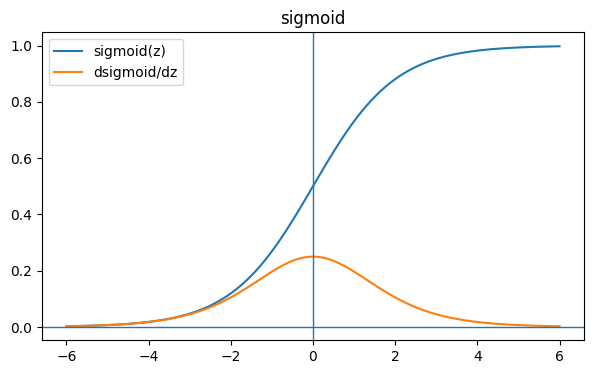

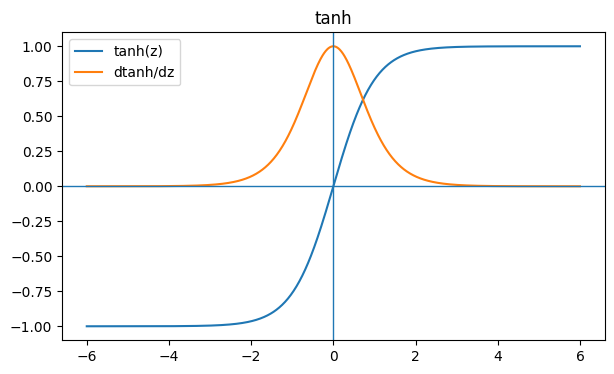

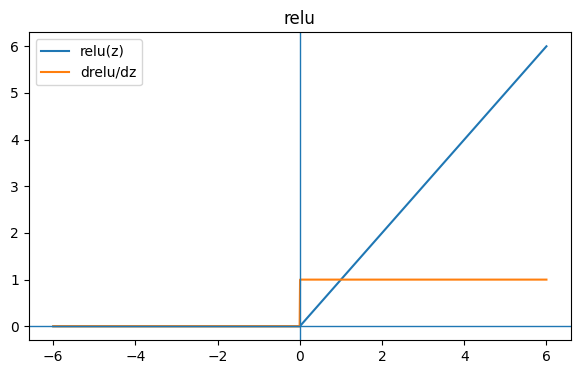

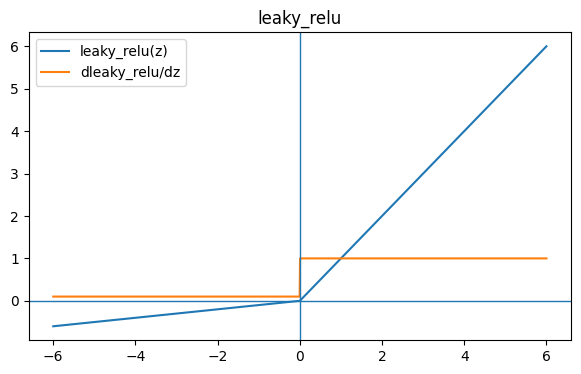

In [9]:
xs = np.linspace(-6, 6, 1200)

def set_figsize(w, h):
    plt.figure(figsize=(w, h))

def plot_act_and_grad(name, f, df=None):
    set_figsize(7, 4)
    plt.plot(xs, f(xs), label=f"{name}(z)")
    if df is not None:
        plt.plot(xs, df(xs), label=f"d{name}/dz")
    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)
    plt.title(name)
    plt.legend()
    plt.show()

plot_act_and_grad('sigmoid', sigmoid, d_sigmoid)
plot_act_and_grad('tanh', tanh, d_tanh)
plot_act_and_grad('relu', relu, d_relu)
plot_act_and_grad('leaky_relu', lambda z: leaky_relu(z, 0.1), lambda z: d_leaky_relu(z, 0.1))


## 3) Saturación y desaparición del gradiente (vanishing gradient)

Cuando una activación **satura**, su derivada se hace muy pequeña, lo que dificulta el aprendizaje en redes profundas.

### Ejercicio 3.1 — Derivada promedio por región
Calcula en `xs`:
- media de `d_sigmoid` en `|z|>4`
- media de `d_tanh` en `|z|>4`
- media de `d_relu` en `|z|>4`

Interpreta: ¿por qué ReLU suele entrenar mejor en redes profundas que sigmoid/tanh (en muchos casos)?

In [10]:
mask = np.abs(xs) > 4

avg_sig = d_sigmoid(xs)[mask].mean()
avg_tan = d_tanh(xs)[mask].mean()
avg_relu = d_relu(xs)[mask].mean()

avg_sig, avg_tan, avg_relu

(np.float64(0.00772705949833878),
 np.float64(0.000326759819549402),
 np.float64(0.5))

## 4) Una neurona como clasificador: frontera de decisión

Para clasificación binaria, se usa típicamente:
- salida $\hat{y} = f(z)$ como probabilidad
- decisión: $\hat{y} > 0.5 \Leftrightarrow z>0$

La frontera de decisión de **una neurona** es lineal: WX + b = 0.

### Ejercicio 4.1 — Visualiza frontera de decisión
Genera datos 2D separables linealmente y dibuja:
- los puntos
- la línea `WX + b = 0`

Luego cambia la activación (sigmoid vs tanh vs relu) y discute:
- La frontera cambia o no cambia. ¿Por qué?
- ¿Qué cambia entonces cuando cambias activación?

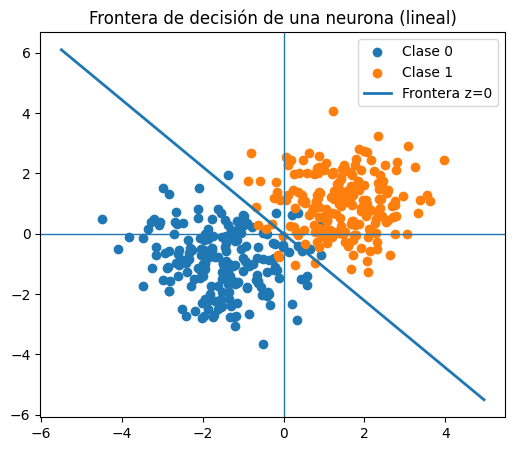

Ejemplo de rangos:
sigmoid: (np.float64(0.0064369703330648745), np.float64(0.9978722297834443))
tanh:    (np.float64(-0.999916057106308), np.float64(0.9999909065727028))
relu:    (np.float64(0.0), np.float64(6.1505506571391155))


In [11]:
# Datos sintéticos separables
n = 200
X0 = np.random.randn(n, 2) + np.array([-1.5, -1.0])
X1 = np.random.randn(n, 2) + np.array([ 1.5,  1.0])
X = np.vstack([X0, X1])
y = np.array([0]*n + [1]*n)

w = np.array([1.0, 0.9])
b = 0.0

set_figsize(6, 5)
plt.scatter(X0[:,0], X0[:,1], label='Clase 0')
plt.scatter(X1[:,0], X1[:,1], label='Clase 1')

# línea w1*x + w2*y + b = 0 -> y = -(w1/w2) x - b/w2
xx = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200)
yy = -(w[0]/w[1]) * xx - b/w[1]
plt.plot(xx, yy, linewidth=2, label='Frontera z=0')

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.legend()
plt.title('Frontera de decisión de una neurona (lineal)')
plt.show()

# Comparación de salidas para distintas activaciones
Z = X @ w + b
out_sig = sigmoid(Z)
out_tan = tanh(Z)
out_relu = relu(Z)

print('Ejemplo de rangos:')
print('sigmoid:', (out_sig.min(), out_sig.max()))
print('tanh:   ', (out_tan.min(), out_tan.max()))
print('relu:   ', (out_relu.min(), out_relu.max()))

## 5) Softmax y competencia entre clases

Softmax convierte un vector de logits $z \in \mathbb{R}^K$ en probabilidades que suman 1.

### Ejercicio 5.1 — Propiedades de softmax
1. Comprueba numéricamente que `softmax(z + c)` da lo mismo que `softmax(z)` para un escalar `c`.
2. Muestra cómo cambia la entropía al escalar logits: `softmax(alpha*z)` para `alpha` grande vs pequeño.

📌 Interpreta: relación con "confianza" del modelo.

In [ ]:
z = np.array([2.0, 1.0, -0.5])
c = 10.0

p1 = softmax(z)
p2 = softmax(z + c)
print('Invarianza al desplazamiento:', np.allclose(p1, p2))
print('p:', p1)

def entropy(p):
    p = np.clip(p, 1e-12, 1)
    return -(p * np.log(p)).sum()

for alpha in [0.5, 1.0, 2.0, 5.0]:
    p = softmax(alpha * z)
    print('alpha=', alpha, 'p=', np.round(p, 4), 'H=', round(entropy(p), 4))

Invarianza al desplazamiento: True
p: [0.68967209 0.25371618 0.05661173]
alpha= 0.5 p= [0.5283 0.3204 0.1513] H= 0.9876
alpha= 1.0 p= [0.6897 0.2537 0.0566] H= 0.7668
alpha= 2.0 p= [0.8756 0.1185 0.0059] H= 0.3993
alpha= 5.0 p= [0.9933 0.0067 0.    ] H= 0.0402


## 6) Mini-proyecto final

### Proyecto — Red Neuronal de 3 capas (con keras) y comparación de activaciones
Implementa una red de 3 capas

Tareas:
1. Entrena en un dataset no lineal (por ejemplo, dos lunas o círculos). Puedes generarlo a mano con ruido.
2. Compara activaciones en la capa oculta (la segunda): tanh vs ReLU vs Leaky ReLU.
3. Reporta:
   - pérdida vs iteraciones
   - accuracy
   - visualización de frontera (malla 2D)

Pistas:
- Para la capa oculta, una activación centrada (tanh) a veces ayuda.
- ReLU suele converger rápido pero puede morir si hay sesgos/escala mal.

Una vez implementada, razona:
- ¿qué activación funcionó mejor y por qué crees?


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(7)
tf.random.set_seed(7)

def make_two_moons(n=800, noise=0.50, seed=1):
    rng = np.random.default_rng(seed)
    n1 = n // 2
    n2 = n - n1

    t1 = rng.uniform(0, np.pi, size=n1)
    t2 = rng.uniform(0, np.pi, size=n2)

    x1 = np.c_[np.cos(t1), np.sin(t1)]
    x2 = np.c_[1 - np.cos(t2), -np.sin(t2) - 0.5]

    X = np.vstack([x1, x2])
    y = np.hstack([np.zeros(n1, dtype=int), np.ones(n2, dtype=int)])

    X += rng.normal(0, noise, size=X.shape)

    idx = rng.permutation(n)
    return X[idx].astype(np.float32), y[idx].astype(np.float32)

X, y = make_two_moons()

def build_model_simple(second_activation="tanh", hidden1=16, hidden2=16, lr=0.01, leaky_alpha=0.1):
    model = keras.Sequential()
    model.add(layers.Input(shape=(2,)))

    # Capa 1 (oculta) fija
    model.add(layers.Dense(hidden1, activation="relu"))

    # Capa 2 (oculta) variable
    if second_activation in ["tanh", "relu"]:
        model.add(layers.Dense(hidden2, activation=second_activation))
    elif second_activation == "leaky_relu":
        model.add(layers.Dense(hidden2))                # sin activación
        model.add(layers.LeakyReLU(negative_slope=leaky_alpha))
    else:
        raise ValueError("Usa: tanh | relu | leaky_relu")

    # Salida
    model.add(layers.Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


tanh final loss= 0.1123 final acc= 0.95
relu final loss= 0.1134 final acc= 0.9516
leaky_relu final loss= 0.1041 final acc= 0.9531


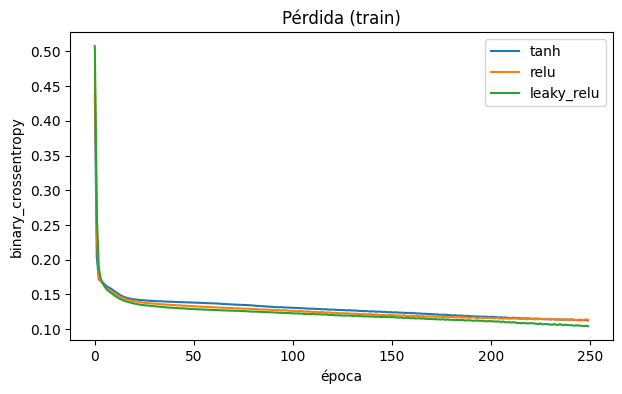

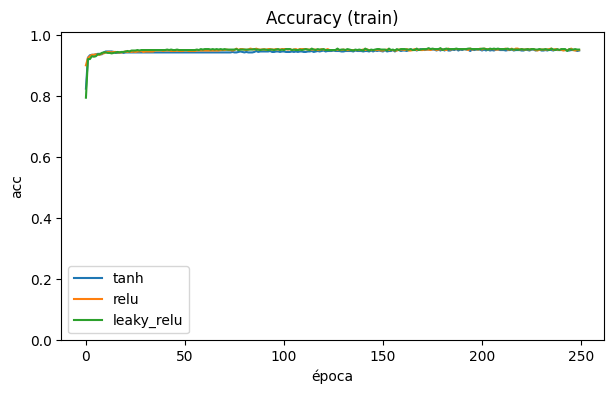

In [ ]:
def train_and_plot(acts=("tanh","relu","leaky_relu"), epochs=200, batch_size=64, lr=0.01):
    models, histories = {}, {}

    for act in acts:
        m = build_model_simple(second_activation=act, lr=lr)
        h = m.fit(X, y, validation_split=0.2, epochs=epochs, batch_size=batch_size, verbose=0)

        models[act] = m
        histories[act] = h
        print(act, "final loss=", round(h.history["loss"][-1], 4),
              "final acc=", round(h.history["accuracy"][-1], 4))

    # loss
    plt.figure(figsize=(7,4))
    for act, h in histories.items():
        plt.plot(h.history["loss"], label=act)
    plt.title("Pérdida (train)")
    plt.xlabel("época")
    plt.ylabel("binary_crossentropy")
    plt.legend()
    plt.show()

    # accuracy
    plt.figure(figsize=(7,4))
    for act, h in histories.items():
        plt.plot(h.history["accuracy"], label=act)
    plt.title("Accuracy (train)")
    plt.xlabel("época")
    plt.ylabel("acc")
    plt.ylim(0, 1.01)
    plt.legend()
    plt.show()

    return models, histories

models, histories = train_and_plot(epochs=250, lr=0.01)


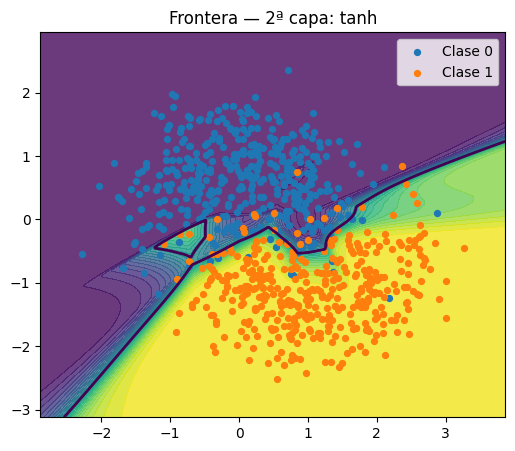

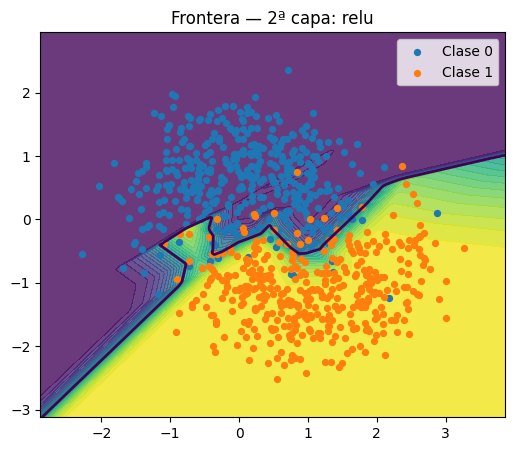

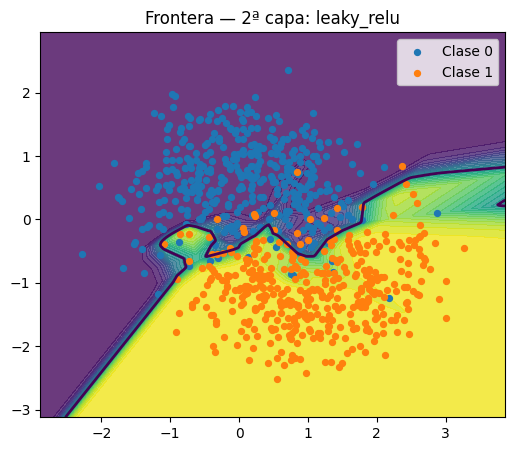

In [ ]:
def plot_decision_boundary(model, X, y, title=""):
    x_min, x_max = X[:,0].min() - 0.6, X[:,0].max() + 0.6
    y_min, y_max = X[:,1].min() - 0.6, X[:,1].max() + 0.6

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

    probs = model.predict(grid, verbose=0).reshape(xx.shape)

    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, probs, levels=30, alpha=0.8)
    plt.contour(xx, yy, probs, levels=[0.5], linewidths=2)
    plt.scatter(X[y==0,0], X[y==0,1], s=18, label="Clase 0")
    plt.scatter(X[y==1,0], X[y==1,1], s=18, label="Clase 1")
    plt.title(title)
    plt.legend()
    plt.show()

for act, m in models.items():
    plot_decision_boundary(m, X, y, title=f"Frontera — 2ª capa: {act}")
